In [1]:
import numpy as np

In [7]:
def shell_offsets(max_r):
    shells = {}
    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz
        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        coords = np.column_stack([dx[mask], dy[mask], dz[mask]]).astype(np.int16)
        shells[r] = coords
    return shells

In [19]:
def shell_offsets(max_r):
    shells = []
    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz
        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        coords = np.column_stack([dx[mask], dy[mask], dz[mask]]).astype(np.int16)
        shells.append(coords)   # ← 用 append 比較實際
    return shells  # ← shell 是 object array

In [17]:
def build_shell_cube(max_r):
    """
    回傳一個 3D cube，中心為 (max_r, max_r, max_r)，
    在球殼 r 的位置賦值為 r，其餘為 0。
    """
    size = 2 * max_r + 1
    cube = np.zeros((size, size, size), dtype=np.int16)

    for r in range(1, max_r + 1):
        rng = np.arange(-r, r + 1)
        dx, dy, dz = np.meshgrid(rng, rng, rng, indexing="ij")
        dist2 = dx*dx + dy*dy + dz*dz

        mask = (dist2 <= r*r) & (dist2 > (r-1)*(r-1))
        # 把偏移座標轉成 cube 的索引
        x_idx = dx[mask] + max_r
        y_idx = dy[mask] + max_r
        z_idx = dz[mask] + max_r

        cube[x_idx, y_idx, z_idx] = r

    return cube

In [18]:
build_shell_cube(30)

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [20]:
shell_offsets(30)

[array([[-1,  0,  0],
        [ 0, -1,  0],
        [ 0,  0, -1],
        [ 0,  0,  1],
        [ 0,  1,  0],
        [ 1,  0,  0]], dtype=int16),
 array([[-2,  0,  0],
        [-1, -1, -1],
        [-1, -1,  0],
        [-1, -1,  1],
        [-1,  0, -1],
        [-1,  0,  1],
        [-1,  1, -1],
        [-1,  1,  0],
        [-1,  1,  1],
        [ 0, -2,  0],
        [ 0, -1, -1],
        [ 0, -1,  1],
        [ 0,  0, -2],
        [ 0,  0,  2],
        [ 0,  1, -1],
        [ 0,  1,  1],
        [ 0,  2,  0],
        [ 1, -1, -1],
        [ 1, -1,  0],
        [ 1, -1,  1],
        [ 1,  0, -1],
        [ 1,  0,  1],
        [ 1,  1, -1],
        [ 1,  1,  0],
        [ 1,  1,  1],
        [ 2,  0,  0]], dtype=int16),
 array([[-3,  0,  0],
        [-2, -2, -1],
        [-2, -2,  0],
        [-2, -2,  1],
        [-2, -1, -2],
        [-2, -1, -1],
        [-2, -1,  0],
        [-2, -1,  1],
        [-2, -1,  2],
        [-2,  0, -2],
        [-2,  0, -1],
        [-2,  0,  1],
  

In [21]:
import numpy as np

def build_distance_shell_ball(max_r):
    """
    建立一個「由不同大小球殼組成的距離球」3D cube。

    回傳一個整數 cube，shape = (2*max_r+1, 2*max_r+1, 2*max_r+1)
    - 中心 (max_r, max_r, max_r) 當作球心
    - 對於 dist = sqrt(dx^2 + dy^2 + dz^2) <= max_r：
        value = ceil(dist)   → 第幾層球殼 (1, 2, ..., max_r)
    - 對於 dist > max_r：
        value = -1           → 球外的區域
    """
    size = 2 * max_r + 1
    coords = np.arange(-max_r, max_r + 1)

    dx, dy, dz = np.meshgrid(coords, coords, coords, indexing="ij")
    dist = np.sqrt(dx*dx + dy*dy + dz*dz)

    # 先用 ceil 把距離量化成 0,1,...,max_r
    shells = np.ceil(dist).astype(np.int16)

    # 球外的地方標成 -1
    shells[dist > max_r] = -1

    # 中心點 dist = 0，ceil(0)=0，這裡若希望最裡面也算「第 1 層」，就改成 1
    center = max_r
    shells[center, center, center] = 1

    return shells

In [ ]:
build_distance_shell_ball(3)

(7, 7, 7)

In [9]:
import numpy as np

def build_ball_offsets(max_r):
    """
    建立「距離球殼」的 offsets：
      - offsets: (N, 3)，每列是 (dv, dz, dx)
      - shell_k: (N,)，每個 offset 對應的殼層 index (1..max_r)

    定義：
      dist = sqrt(dv^2 + dz^2 + dx^2)
      1 <= ceil(dist) <= max_r 的點會被保留
    """
    coords = np.arange(-max_r, max_r + 1)
    dv, dz, dx = np.meshgrid(coords, coords, coords, indexing="ij")
    dist = np.sqrt(dv*dv + dz*dz + dx*dx)

    # 只保留 dist <= max_r 的點
    mask = dist <= max_r
    dv_sel = dv[mask]
    dz_sel = dz[mask]
    dx_sel = dx[mask]
    dist_sel = dist[mask]

    # 殼層 index：ceil(dist)，中心點 dist=0 → 設成 1 層
    shell_k = np.ceil(dist_sel).astype(np.int16)
    shell_k[dist_sel == 0.0] = 1

    offsets = np.column_stack([dv_sel, dz_sel, dx_sel]).astype(np.int16)
    return offsets, shell_k

In [10]:
def apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r):
    """
    給定一條 3D 線 (v_line, z_line, x_line)，在 cube 裡為每個 voxel
    標上「距離這條線最近的球殼 index」。

    回傳:
      shell_cube: shape = cube_shape，int16
        - 值 = 1..max_r → 距離線大約為該殼層
        - 值 = -1        → 超出 max_r 以外（沒有被任何球殼覆蓋）
    """
    nv, nz, nx = cube_shape
    shell_cube = np.full(cube_shape, -1, dtype=np.int16)

    # 預先算好球殼 offsets 和對應的殼層 index
    offsets, shell_k = build_ball_offsets(max_r)
    dv_off = offsets[:, 0]
    dz_off = offsets[:, 1]
    dx_off = offsets[:, 2]

    v_line = np.asarray(v_line, dtype=int)
    z_line = np.asarray(z_line, dtype=int)
    x_line = np.asarray(x_line, dtype=int)

    for v0, z0, x0 in zip(v_line, z_line, x_line):
        # 對這個線上的點，把整顆 ball 平移過去
        v_idx = v0 + dv_off
        z_idx = z0 + dz_off
        x_idx = x0 + dx_off

        # 只保留有落在 cube 內的 voxel
        in_bounds = (
            (v_idx >= 0) & (v_idx < nv) &
            (z_idx >= 0) & (z_idx < nz) &
            (x_idx >= 0) & (x_idx < nx)
        )
        if not np.any(in_bounds):
            continue

        v_sel = v_idx[in_bounds]
        z_sel = z_idx[in_bounds]
        x_sel = x_idx[in_bounds]
        k_sel = shell_k[in_bounds]

        # 目前 cube 裡的值
        cur = shell_cube[v_sel, z_sel, x_sel]

        # 更新條件：
        #   - 原本是 -1（還沒被任何球覆蓋）
        #   - 或原本的值 > 新的殼層 index（新球更靠近線）
        update_mask = (cur < 0) | (cur > k_sel)

        shell_cube[v_sel[update_mask],
                   z_sel[update_mask],
                   x_sel[update_mask]] = k_sel[update_mask]

    return shell_cube

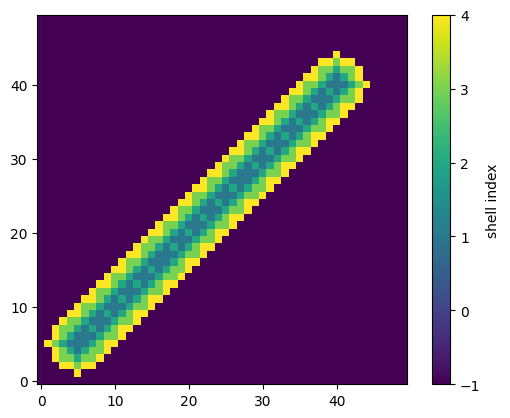

In [12]:
# 假設 cube 是 50×50×50
cube_shape = (50, 50, 50)

# 做一條斜斜的線
t = np.linspace(5, 40, 20).astype(int)
v_line = t
z_line = 25 + 0*t   # 固定在中間
x_line = t          # 對角線

shell_cube = pss.apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r=4)

# 看看某個切片
import matplotlib.pyplot as plt
plt.imshow(shell_cube[:, 25, :], origin="lower")
plt.colorbar(label="shell index")
plt.show()

In [3]:
import PSSpy as pss

In [18]:
offset, shell = pss.build_ball_offsets(3)
print(shell)
print(offset[0:10])

[2 3 3 3 3 3 3]
[[1 1 1]
 [1 1 2]
 [1 2 1]
 [1 2 2]
 [2 1 1]
 [2 1 2]
 [2 2 1]]


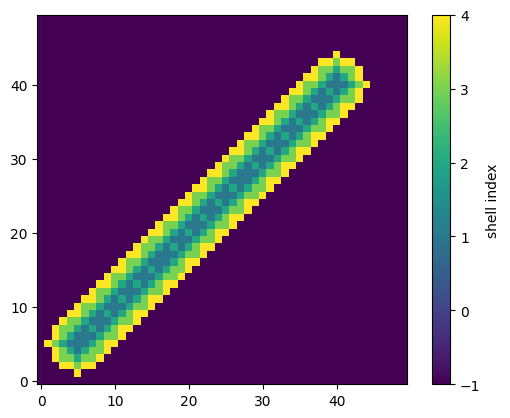

In [23]:
# 假設 cube 是 50×50×50
cube_shape = (50, 50, 50)

# 做一條斜斜的線
t = np.linspace(5, 40, 20).astype(int)
v_line = t
z_line = 25 + 0*t   # 固定在中間
x_line = t          # 對角線

shell_cube = pss.apply_shell_ball_to_line(cube_shape, v_line, z_line, x_line, max_r=4)

# 看看某個切片
import matplotlib.pyplot as plt
plt.imshow(shell_cube[:, 25, :], origin="lower")
plt.colorbar(label="shell index")
plt.show()

In [56]:
import scipy.constants as spc
import PSSpy as pss
Target = "Per-emb-50"
T_factor_range = (14.744, 678)
radius_ref_au = 240
M_star = 2.58
M_SUN_KG = 1.98847e30

Omega_ref = pss.Omega_ref(radius_ref_au, M_star)
P_half_Myr = np.pi / Omega_ref / 1e6 / spc.year
T_range = [T_factor_range[0]*P_half_Myr, T_factor_range[1]*P_half_Myr]

M_0_max = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[0] * 1e6 * spc.year)
M_0_min = M_star * M_SUN_KG * spc.G / (radius_ref_au**3 * T_range[1] * 1e6 * spc.year)

print(f"\n==================== Parameters ({Target}) ====================")
print(f"M_0_min          = {M_0_min:.3e}")
print(f"M_0_max          = {M_0_max:.3e}")
print("===============================================================")


==================== Parameters (Per-emb-50) ====================
M_0_min          = 1.000e+00
M_0_max          = 4.600e+01


In [60]:
rms_moment0 = 3.020265757777e-1

3 * rms_moment0

0.9060797273330999